# Анализ лояльности пользователей Яндекс Афиши <a id='start'></a>
- Автор: Якунина Анна
- Дата: 15.04.2026

## Цели и задачи проекта
### Цель проекта - провести исследовательский анализ данных пользователей Яндекс Афиши.
### Задачи проекта
1. Выгрузить данные из базы данных SQL `data-analyst-afisha` и познакомиться с их содержимым.
2. Подготовить данные к исследовательскому анализу.
3. Создать профиль пользователя.
4. Провести исследовательский анализ исходных данных.
5. Сформулировать итоговый вывод и рекомендации для команды маркетинга.

## Описание данных
Выгрузка из базы данных SQL `data-analyst-afisha` позволила собрать следующие данные:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ ( mobile — мобильные устройства, desktop — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## Содержимое проекта

1. [Загрузка данных и знакомство с ними](#upload)
2. [Предобработка данных](#preprocessing)
3. [Создание профиля пользователя](#profile)
4. [Исследовательский анадиз данных](#research)
5. [Итоговый вывод и рекомендации](#resume)

---
# 1. Загрузка данных и знакомство с ними
<a id='upload'></a>
- Загружаем необходимые библиотеки Python. 


In [1]:
!pip install sqlalchemy -U

In [2]:
!pip install psycopg2 -U

In [3]:
!pip install phik -U

In [4]:
from dotenv import load_dotenv
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from phik import phik_matrix

- Подключаемся к БД `data-analyst-afisha` и выгружаем требуемые данные.

In [5]:
load_dotenv()

db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")

In [6]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_user,
    db_password,
    db_host,
    db_port,
    db_name
)

In [7]:
engine = create_engine(connection_string)

In [8]:
query = '''
SELECT user_id,
       device_type_canonical,
       order_id,
       created_dt_msk AS order_dt,
       created_ts_msk AS order_ts,
       currency_code,
       revenue,
       tickets_count,
       created_dt_msk::date - (LAG(created_dt_msk) OVER(PARTITION BY user_id ORDER BY created_dt_msk))::date AS days_since_prev,
       event_id,
       event_name_code AS event_name,
       event_type_main,
       service_name,
       region_name,
       city_name
FROM afisha.purchases
JOIN afisha.events USING (event_id)
LEFT JOIN afisha.city USING (city_id)
LEFT JOIN afisha.regions USING (region_id)
WHERE device_type_canonical IN ('desktop', 'mobile')
  AND event_type_main != 'фильм'
ORDER BY user_id
'''

In [9]:
afisha = pd.read_sql_query(query, con=engine)

- Знакомимся с выгруженными данными.

In [10]:
afisha.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [11]:
afisha.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Датасет содержит **15 столбцов и 290611 строк**:
- Столбцы `user_id`, `device_type_canonical`, `currency_code`, `event_name`, `event_type_main`, `service_name`, `region_name`, `city_name` содержат строковые данные. Тип `object` здесь подходит.
- В столбцах ` order_dt` и `order_ts` содержатся дата и время создания заказа. Тип `datetime64[ns]` здесь подходит.
- В столбце `revenue` содержится выручка от заказа. Тип `float64` здесь подходит.
- Столбец `order_id`, `tickets_count` и `event_id` содержат числовые данные, представлены типом `int64`. Размерность этих данных можно оптимизировать.
- Столбец `days_since_prev` содержит числовые данные - количество дней от предыдущей покупки пользователя. Представден типом `float64`. Следует привести к типу `integer`.
- Пропуски содержатся только в столбце `days_since_prev`.
- Значения в столбцах соответствуют описанию.
---

- Для приведения выручки к единой валюте — российскому рублю, загружаем данные датасета `final_tickets_tenge_df.csv`.

In [12]:
exchange = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

- Знакомимся с данными датасета `final_tickets_tenge_df.csv`.

In [13]:
exchange.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [14]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет содержит **4 столбца и 357 строк**:
- Столбец `data` содержит дату. Представлен типом `object`. Следует привести к типу `datetime64`.
- Столбец `nominal` содержит числовые данные, представлен типом `int64`. Размерность этих данных можно оптимизировать.
- Столбец `curs` содержит числовые данные, представлен типом `float64`. Размерность этих данных можно оптимизировать.
- Столбец `cdx` содержат строковые данные. Тип `object` здесь подходит.
- Пропусков в данных нет.

---
# 2.  Предобработка данных 
<a id='preprocessing'></a>
## 2.1. Типы данных
- Преобразуем числовые типы данных датафрейма `afisha` с понижением размерности.

In [15]:
for col in ['order_id','tickets_count', 'event_id']:
    afisha[col] = pd.to_numeric(afisha[col], downcast='integer')

In [16]:
afisha['days_since_prev'] = afisha['days_since_prev'].astype('Int16')

In [17]:
afisha.dtypes

user_id                          object
device_type_canonical            object
order_id                          int32
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                      int8
days_since_prev                   Int16
event_id                          int32
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
dtype: object

- Преобразуем числовые типы данных датафрейма `exchange` с понижением размерности.

In [18]:
exchange['data'] = pd.to_datetime(exchange['data'])

In [19]:
exchange['nominal'] = pd.to_numeric(exchange['nominal'], downcast='integer')

In [20]:
exchange['curs'] = pd.to_numeric(exchange['curs'], downcast='float')

In [21]:
exchange.dtypes

data       datetime64[ns]
nominal              int8
curs              float32
cdx                object
dtype: object

---
## 2.2. Подготовка единого датафрейма

- Присоединяем датафреймы `afisha` и `exchange`

In [22]:
merged = afisha.merge(exchange, how='left', left_on='order_dt', right_on='data')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int16         
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

- Создаём дополнительный столбец `revenue_rub` с выручкой в российских рублях

In [23]:
def to_rub(row):
    if row['currency_code'] == 'kzt':
        return round(row['revenue'] * row['curs'] / 100, 2)
    else:
        return row['revenue']

In [24]:
merged['revenue_rub'] = merged.apply(to_rub, axis=1)

In [25]:
merged[merged['currency_code'] == 'kzt'].head(1)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,nominal,curs,cdx,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.1,4,20,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-17,100,19.012501,kzt,98.5


- Создаём датафрейм `df` для дальнейшего анализа

In [26]:
df = merged[afisha.columns.tolist() + ['revenue_rub']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int16         
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

- Подготовлен единый датафрейм `df`, содержащий **290611 строк и 16 столбцов**:
    - Создан дополнительный столбец `revenue_rub` с выручкой в российских рублях.
    - Пропуски содержатся в столбце `days_since_prev`.
    - Типы данных соответствуют содержимому.
    - Значения в столбцах соответствуют описанию.

---
## 2.3. Наличие пропусков в данных
- Считаем количество пропусков в столбцах датафрейма `merged` в абсолютных и относительных значениях.

In [27]:
df.isna().sum() \
    .to_frame(name='Кол-во') \
    .sort_values(by='Кол-во', ascending=False) \
    .assign(Процент=lambda x: x['Кол-во'] / len(df) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
days_since_prev,21933,7.55%
user_id,0,0.00%
device_type_canonical,0,0.00%
order_id,0,0.00%
order_dt,0,0.00%
order_ts,0,0.00%
currency_code,0,0.00%
revenue,0,0.00%
tickets_count,0,0.00%
event_id,0,0.00%


- Пропуски наблюдаются в столбце `days_since_prev`. 
    - В столбце содержатся данные о количестве дней с предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено.
    - Пропуски соответствуют имеющимся у нас данным (группа **MAR**). **Оставляем пропуски как есть**.

---
## 2.4. Явные и неявные дубликаты в данных

- Проверим полные дубликаты в датафрейме `df`

In [28]:
df.duplicated().sum()

np.int64(0)

- Проверим неявные дубликаты в датафрейме `df`

In [29]:
df.duplicated(subset=['user_id', 'order_ts', 'event_id']).sum()

np.int64(120)

- Сохраняем количество строк в исходном датафрейме

In [30]:
len_src_df = len_df = len(df)
len_df

290611

- Удаляем дубликаты

In [31]:
df = df.sort_values(by=df.columns.tolist())
df = df.drop_duplicates(subset=['user_id', 'order_ts', 'event_id'], keep='last')

- Считаем количество удаленных строк в абсолютном и относительном выражении

In [32]:
del_rows = len_df - len(df)
print(f'Количество удаленных строк: {del_rows} - {round(del_rows/ len_df * 100, 2)}%')

Количество удаленных строк: 120 - 0.04%


---
## 2.5. Значения в ключевых столбцах

- Проверяем уникальные значения в категориальных столбцах

In [33]:
for col in ['device_type_canonical', 'currency_code', 'event_type_main']:
    print(f'Уникальные значения в столбце {col}:')
    print(f'{df[col].sort_values().unique()}\n')

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце event_type_main:
['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки']



- Оцениваем статистические показатели по столбцу `tickets_count`

In [34]:
df['tickets_count'].describe().round().astype(int)

count    290491
mean          3
std           1
min           1
25%           2
50%           3
75%           4
max          57
Name: tickets_count, dtype: int64

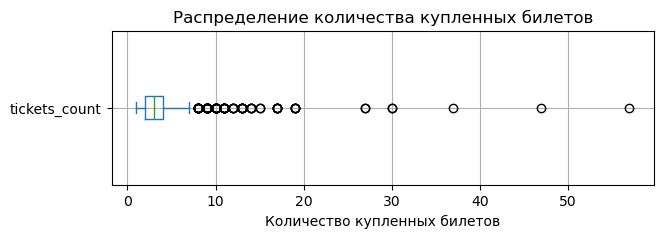

In [35]:
df['tickets_count'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение количества купленных билетов',
    xlabel='Количество купленных билетов',
    vert=False
)

plt.show()

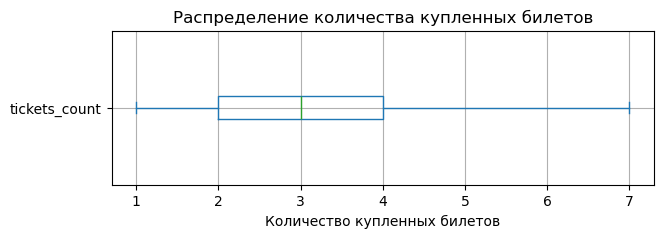

In [36]:
df['tickets_count'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение количества купленных билетов',
    xlabel='Количество купленных билетов',
    vert=False,
    showfliers=False
)

plt.show()

- Данные по количеству купленных билетов имеют правое асимметричное распределение:
    - среднее значение - **3**, медиана -  **3**, стандартное отклонение - **1**;
    - минимальное значение - **1**, максимальное - **57**.
- **Высокие** значения можно отнести к **выбросам**. Однако сами значения не выглядят ошибкой, и такое количество купленных билетов вполне допустимо.

- Оцениваем статистические показатели по столбцу `revenue_rub`

In [37]:
df['revenue_rub'].describe().round(2)

count    290491.00
mean        555.65
std         875.59
min         -90.76
25%         113.97
50%         351.25
75%         802.05
max       81174.54
Name: revenue_rub, dtype: float64

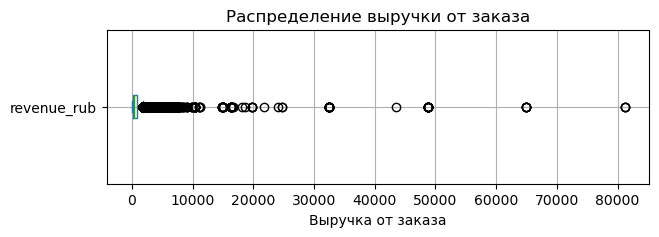

In [38]:
df['revenue_rub'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение выручки от заказа',
    xlabel='Выручка от заказа',
    vert=False
)

plt.show()

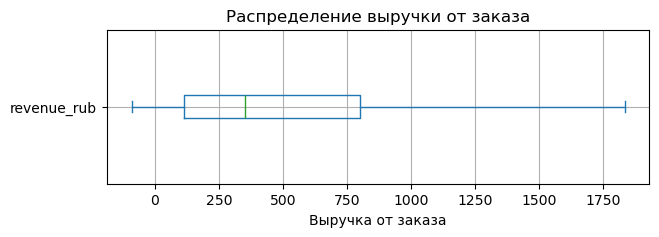

In [39]:
df['revenue_rub'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение выручки от заказа',
    xlabel='Выручка от заказа',
    vert=False,
    showfliers=False
    
)

plt.show()

- Данные по выручке от заказа имеют правое асимметричное распределение:
    - среднее значение - **556**, медиана -  **351**, стандартное отклонение — **876**;
    - минимальное значение - **-91**, максимальное - **81175**.
- **Аномальные** значения, **меньше 0**, присутствуют. Их можно отнести к ошибкам при заполнении данных.
- **Высокие** значения можно отнести к **выбросам**. Однако сами значения не выглядят ошибкой и вполне допустимы.

- Сохраняем текущее количество строк в датафрейме

In [40]:
len_df = len(df)
len_df

290491

- Отфильтруем значения **больше 99** процентиля и **меньше 0**

In [41]:
mask = (df['revenue_rub'] > df['revenue_rub'].quantile(0.99)) | (df['revenue_rub'] < 0)
df = df[~mask]

- Считаем количество отфильтрованных строк в абсолютном и относительном выражении

In [42]:
del_rows = len_df - len(df)
print(f'Количество удаленных строк: {del_rows} - {round(del_rows/ len_df * 100, 2)}%')

Количество удаленных строк: 3203 - 1.1%


- Сохраняем текущее количество строк в датафрейме `df`

In [43]:
len_df = len(df)
len_df

287288

- Считаем общее количество удаленных из исходного датафрейма строк в абсолютном и относительном выражении

In [44]:
del_rows = len_src_df - len(df)
print(f'Количество удаленных строк: {del_rows} - {round(del_rows/ len_src_df * 100, 2)}%')

Количество удаленных строк: 3323 - 1.14%


---
## Выводы
- Для дальнейшего анализа подготовлен датафрейм `df`, содержащий **287288 строк и 16 столбцов**.
- В результате предобработки данных были выполнены следующие действия:
    - Преобразовали числовые типы данных с понижением размерности: столбцы `order_id`,`tickets_count`, `event_id`.
    - Изучены пропуски в данных. Пропуски обнаружены в столбце `days_since_prev`. **Все пропуски оставили как есть**.
    - Создали дополнительный столбец `revenue_rub` с выручкой в российских рублях.
    - Обработаны явные и неявные дубликаты в данных: **120 дубликатов удалено**.
    - Проверили значения в ключевых столбцах: **3203 строки отфильтровано**.  
    - Создали 1 дополнительный столбец `revenue_rub` с выручкой в российских рублях.
- Всего удалено **3323** строки - **1.14%** данных.

# 3. Создание профиля пользователя
<a id='profile'></a>
## Задача 3.1. Построение профиля пользователя

- Находим для каждого пользователя:
    - дату первого и последнего заказа - `first_order_dt` и `last_order_dt`;
    - устройство, с которого был сделан первый заказ - `device_type`;
    - регион, в котором был сделан первый заказ - `region_name`;
    - билетного партнёра, к которому обращались при первом заказе - `service_name`;
    - жанр первого посещённого мероприятия - `event_type_main`;
    - общее количество заказов - `total_orders`;
    - средняя выручка с одного заказа в рублях - `avg_revenue_rub`;
    - среднее количество билетов в заказе - `avg_tickets_count`;
    - среднее время между заказами - `avg_days`:
        - равно -1, если у пользователя только один заказ.

In [45]:
profile = df.sort_values(by='order_ts') \
    .groupby('user_id', as_index=False) \
    .agg(
        first_order_dt=('order_dt', 'first'),
        last_order_dt=('order_dt', 'last'),
        device_type=('device_type_canonical', 'first'),
        region_name=('region_name', 'first'),
        service_name=('service_name', 'first'),
        event_type_main=('event_type_main', 'first'),
        total_orders=('order_id', 'count'),
        avg_revenue_rub=('revenue_rub', lambda x: x.mean().round(2)),
        avg_tickets_count=('tickets_count', lambda x: x.mean().round().astype(int)),
        avg_days=('order_ts', lambda x: x.diff().mean() / pd.Timedelta(days=1)) 
)
profile['avg_days'] = profile['avg_days'].fillna(-1).round().astype(int)

In [46]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21838 entries, 0 to 21837
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21838 non-null  object        
 1   first_order_dt     21838 non-null  datetime64[ns]
 2   last_order_dt      21838 non-null  datetime64[ns]
 3   device_type        21838 non-null  object        
 4   region_name        21838 non-null  object        
 5   service_name       21838 non-null  object        
 6   event_type_main    21838 non-null  object        
 7   total_orders       21838 non-null  int64         
 8   avg_revenue_rub    21838 non-null  float64       
 9   avg_tickets_count  21838 non-null  int64         
 10  avg_days           21838 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(5)
memory usage: 1.8+ MB


- Добавляем бинарные признаки:
    - is_two — совершил ли пользователь 2 и более заказа;
    - is_five — совершил ли пользователь 5 и более заказов.

In [47]:
profile['is_two'] = (profile['total_orders'] >= 2).astype(int)
profile['is_five'] = (profile['total_orders'] >= 5).astype(int)

In [48]:
profile['is_two'].value_counts(dropna=False)

is_two
1    13475
0     8363
Name: count, dtype: int64

In [49]:
profile['is_five'].value_counts(dropna=False)

is_five
0    15508
1     6330
Name: count, dtype: int64

- Оптимизируем числовые типы

In [50]:
for col in ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days', 'is_two', 'is_five']:
   cast = 'float' if col == 'avg_revenue_rub' else 'integer'
   profile[col] = pd.to_numeric(profile[col], downcast=cast)

In [51]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [52]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21838 entries, 0 to 21837
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21838 non-null  object        
 1   first_order_dt     21838 non-null  datetime64[ns]
 2   last_order_dt      21838 non-null  datetime64[ns]
 3   device_type        21838 non-null  object        
 4   region_name        21838 non-null  object        
 5   service_name       21838 non-null  object        
 6   event_type_main    21838 non-null  object        
 7   total_orders       21838 non-null  int16         
 8   avg_revenue_rub    21838 non-null  float32       
 9   avg_tickets_count  21838 non-null  int8          
 10  avg_days           21838 non-null  int16         
 11  is_two             21838 non-null  int8          
 12  is_five            21838 non-null  int8          
dtypes: datetime64[ns](2), float32(1), int16(2), int8(3), object(5

In [53]:
profile.head(6)

,user_id,first_order_dt,last_order_dt,device_type,region_name,service_name,event_type_main,total_orders,avg_revenue_rub,avg_tickets_count,avg_days,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4,-1,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3,75,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,3,51,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4,-1,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,2,16,1,0
5,000cf0659a9f40f,2024-06-20,2024-06-21,mobile,Широковская область,Лови билет!,концерты,13,1175.81,3,0,1,1


#### Выводы
- Подготовлен датафрейм `profile` с профилями пользователей:
    - содержит **21838 строк** и **13 столбцов**;
    - значение в столбце `avg_days` равно **-1**, если у пользователя только один заказ;
    - **пропусков** в столбцах **нет**.
- Типы данных соответствуют содержимому.
- Значения в столбцах соответствуют описанию.

---
## Задача 3.2. Изучение данных о профилях пользователей
- Используя данные о профилях пользователей, рассчитайте:
    - общее число пользователей в выборке;
    - среднюю выручку с одного заказа;
    - долю пользователей, совершивших 2 и более заказа;
    - долю пользователей, совершивших 5 и более заказов.
- Изучите статистические показатели:
    - по общему числу заказов;
    - по среднему числу билетов в заказе;
    - по среднему количеству дней между покупками.

In [54]:
pd.DataFrame({
    'Значение': [
        f'{profile['user_id'].count():}',
        profile['avg_revenue_rub'].mean(),
        profile['is_two'].mean(),
        profile['is_five'].mean()
    ]
}, index=['Кол-во пользователей', 'Средняя выручка с заказа', 'Доля: 2 и более заказа', 'Доля: 5 и более заказов'])

,Значение
Кол-во пользователей,21838
Средняя выручка с заказа,545.02
Доля: 2 и более заказа,0.62
Доля: 5 и более заказов,0.29


---
- Изучим стистические показатели по общему числу заказов

In [55]:
profile['total_orders'].describe().round().astype(int)

count    21838
mean        13
std        122
min          1
25%          1
50%          2
75%          5
max      10167
Name: total_orders, dtype: int64

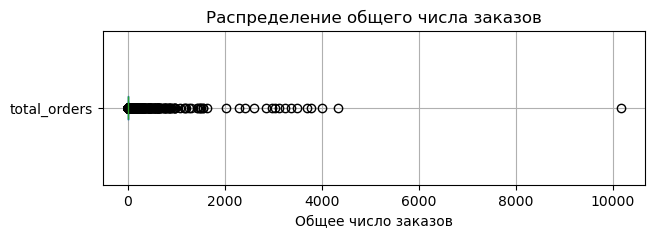

In [56]:
profile['total_orders'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение общего числа заказов',
    xlabel='Общее число заказов',
    vert=False
)

plt.show()

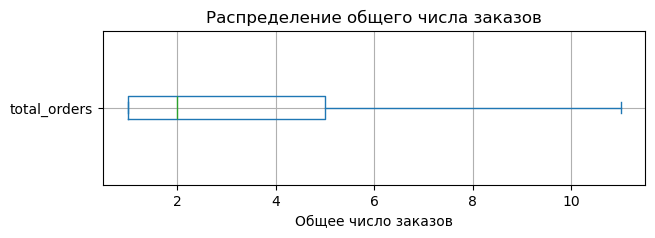

In [57]:
profile['total_orders'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение общего числа заказов',
    xlabel='Общее число заказов',
    vert=False,
    showfliers=False
)

plt.show()

- Данные **по общему числу заказов** имеют правое асимметричное распределение:
    - среднее значение - **13**, медиана -  **2**, стандартное отклонение — **122**;
    - минимальное значение - **1**, максимальное - **10167**.
- **Аномальные** значений **нет**.
- **Высокие** значения можно отнести к **выбросам**. Однако сами значения не выглядят ошибкой и вполне допустимы.

---
- Изучим стистические показатели по среднему числу билетов в заказе

In [58]:
profile['avg_tickets_count'].describe().round().astype(int)

count    21838
mean         3
std          1
min          1
25%          2
50%          3
75%          3
max         11
Name: avg_tickets_count, dtype: int64

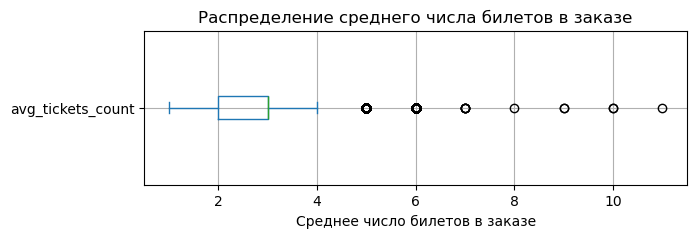

In [59]:
profile['avg_tickets_count'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение среднего числа билетов в заказе',
    xlabel='Среднее число билетов в заказе',
    vert=False
)

plt.show()

- Данные **по среднему числу билетов в заказе** имеют симметричное распределение:
    - среднее значение - **3**, медиана -  **3**, стандартное отклонение — **1**;
    - минимальное значение - **1**, максимальное - **11**.
- **Аномальных** значений **нет**.
- **Высокие** значения можно отнести к **выбросам**. Однако сами значения не выглядят ошибкой и вполне допустимы.

---
- Изучим стистические показатели по среднему количеству дней между покупками

In [60]:
profile['avg_days'].describe().round().astype(int)

count    21838
mean         9
std         19
min         -1
25%         -1
50%          0
75%         12
max        148
Name: avg_days, dtype: int64

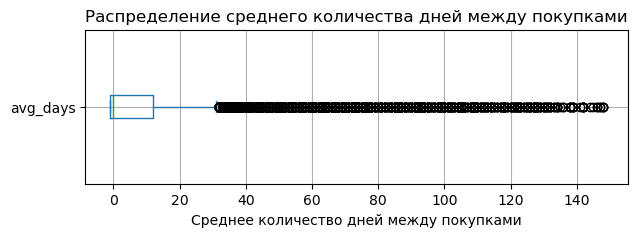

In [61]:
profile['avg_days'].plot(
    kind='box',
    figsize=(7, 2),
    grid=True,
    title='Распределение среднего количества дней между покупками',
    xlabel='Cреднее количество дней между покупками',
    vert=False
)

plt.show()

- Данные **по среднему количеству дней** между покупками имеют правое асимметричное распределение:
    - среднее значение - **9**, медиана -  **0**, стандартное отклонение — **19**;
    - минимальное значение - **-1**, максимальное - **148**.
- **Аномальных** значений **нет**.
- **Высокие** значения можно отнести к **выбросам**. Однако сами значения не выглядят ошибкой и вполне допустимы.

### Выводы
- Данные о профилях пользователей **достаточны по объему**.
- **Аномальных** значений **нет**.
- **Высокие** значения **присутсвуют**, но вполне **допустимы**.

---
# 4. Исследовательский анализ данных
<a id='research'></a>

## 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу
### Задача 4.1.1. Распределение пользователей по признакам
- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. 
- Равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

- Изучаем распределение пользователей **по типу их первого мероприятия**

In [62]:
profile['event_type_main'].value_counts() \
    .to_frame(name='Кол-во') \
    .assign(Процент=lambda x: x['Кол-во'] / len(profile) * 100) \
.style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
event_type_main,,
концерты,9647,44.18%
другое,5465,25.03%
театр,4295,19.67%
стендап,1118,5.12%
спорт,801,3.67%
выставки,417,1.91%
ёлки,95,0.44%


- Изучаем распределение пользователей **по типу устройства**, с которого совершена первая покупка

In [63]:
profile['device_type'].value_counts() \
    .to_frame(name='Кол-во') \
    .assign(Процент=lambda x: x['Кол-во'] / len(profile) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
device_type,,
mobile,18090,82.84%
desktop,3748,17.16%


- Изучим распределение пользователей **по региону** проведения мероприятия из первого заказа

In [64]:
profile['region_name'].value_counts() \
    .to_frame(name='Кол-во') \
    .assign(Процент=lambda x: x['Кол-во'] / len(profile) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
region_name,,
Каменевский регион,7160,32.79%
Североярская область,3800,17.40%
Широковская область,1236,5.66%
Озернинский край,678,3.10%
Малиновоярский округ,530,2.43%
Шанырский регион,505,2.31%
Травяная область,493,2.26%
Светополянский округ,464,2.12%
Речиновская область,446,2.04%


- Изучим распределение пользователей **по билетному оператору**, продавшему билеты на первый заказ

In [65]:
profile['service_name'].value_counts() \
    .to_frame(name='Кол-во') \
    .assign(Процент=lambda x: x['Кол-во'] / len(profile) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
service_name,,
Билеты без проблем,5204,23.83%
Мой билет,2993,13.71%
Лови билет!,2851,13.06%
Билеты в руки,2592,11.87%
Облачко,2194,10.05%
Весь в билетах,1305,5.98%
Лучшие билеты,1186,5.43%
Прачечная,588,2.69%
Край билетов,459,2.10%


#### Выводы
- **По типу первого мероприятия**:
  - пользователи распределены **неравномерно**;
  - сегмент с наибольшим числом пользователей: **концерты** - **44,2%**.
- **По типу устройства**:
    - пользователи распределены **неравномерно**:
  - **mobile** - **82,8%**;
  - **desktop** - **17,2%**.
- **По региону**:
    - пользователи распределены **неравномерно**:
  - **Каменевский регион** - **32,8%**;
  - **Североярская область** - **17,4%**.
- **По билетному оператору**:
    - пользователи распределены **неравномерно**:
    - **Билеты без проблем** - **23.8%**;
    - **Мой билет** - **13.7%**;
    - **Лови билет!** - **13%**
    - **Билеты в руки**	- **11.9%**;
    - **Облачко** - **10%**.

---
### Задача 4.1.2. Анализ возвратов пользователей
- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком.
- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

- Вычисляем доли пользователей, совершивших **два и более заказа**, в зависимости от **типа первого мероприятия**.

In [66]:
grouped = profile.groupby('event_type_main')['is_two'].mean().sort_values(ascending=False)
grouped

event_type_main
выставки   0.65
театр      0.64
концерты   0.62
стендап    0.61
другое     0.60
спорт      0.56
ёлки       0.56
Name: is_two, dtype: float64

In [67]:
# Функция для отрисовки на графике горизонтальной линии
def plot_axhline(value, label):
    plt.axhline(
        value,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=label + str(value)
)

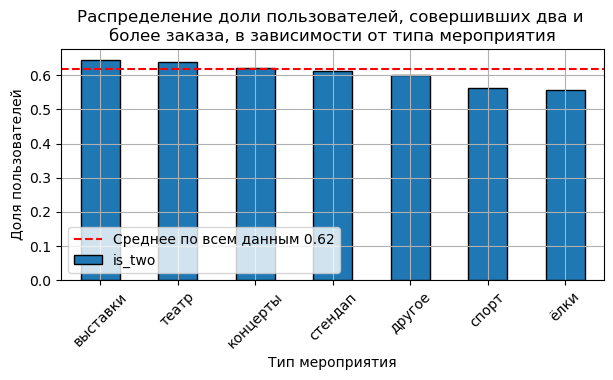

In [68]:
mean_l = profile['is_two'].mean().round(2)

grouped.plot(
    kind='bar',
    figsize=(7, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение доли пользователей, совершивших два и \nболее заказа, в зависимости от типа мероприятия',
    xlabel='Тип мероприятия',
    ylabel='Доля пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

---
- Вычисляем доли пользователей, совершивших **два и более заказа**, в зависимости от **типу устройства**, с которого совершена первая покупка.

In [69]:
grouped = profile.groupby('device_type')['is_two'].mean().sort_values(ascending=False)
grouped

device_type
desktop   0.64
mobile    0.61
Name: is_two, dtype: float64

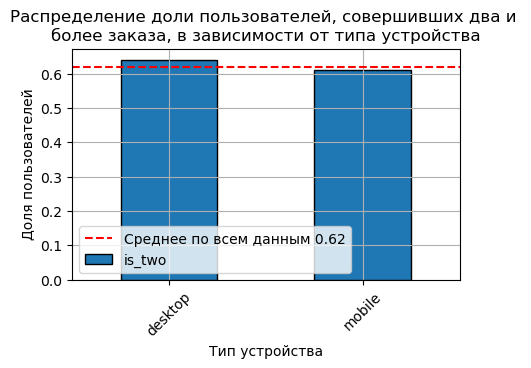

In [70]:
mean_l = profile['is_two'].mean().round(2)

grouped.plot(
    kind='bar',
    figsize=(5, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение доли пользователей, совершивших два и \nболее заказа, в зависимости от типа устройства',
    xlabel='Тип устройства',
    ylabel='Доля пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

---
- Вычисляем долю пользователей, совершивших **два и более заказа**, в зависимости от **региона** проведения мероприятия из первого заказа.
- Отфильтруем сегменты с небольшим количеством пользователей (< 100).

In [71]:
users = profile['region_name'].value_counts()
profile_region = profile[profile['region_name'].isin(users[users >= 100].index)]

In [72]:
grouped = profile_region.groupby('region_name')['is_two'].mean().sort_values(ascending=False)
grouped

region_name
Горицветская область        0.68
Шанырский регион            0.68
Берёзовская область         0.67
Заречная область            0.66
Светополянский округ        0.66
Речицкий регион             0.66
Широковская область         0.65
Североярская область        0.64
Речиновская область         0.64
Ветренский регион           0.64
Каменевский регион          0.63
Травяная область            0.62
Каменноозёрный край         0.60
Зоринский регион            0.60
Яблоневская область         0.60
Медовская область           0.60
Солнечноземская область     0.60
Тепляковская область        0.59
Солнечнореченская область   0.59
Верхоречная область         0.58
Малиновая область           0.58
Лесодальний край            0.57
Травиницкий округ           0.57
Малиновоярский округ        0.56
Лугоградская область        0.56
Серебринская область        0.56
Озернинский край            0.55
Каменноярский край          0.55
Глиногорская область        0.54
Name: is_two, dtype: float64

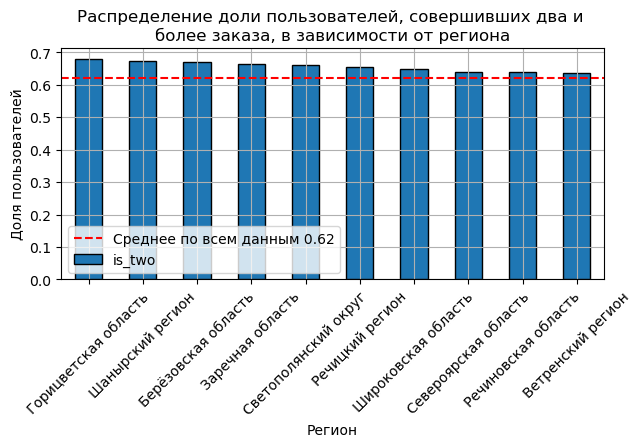

In [73]:
mean_l = profile_region['is_two'].mean().round(2)

grouped.head(10).plot(
    kind='bar',
    figsize=(7, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение доли пользователей, совершивших два и \nболее заказа, в зависимости от региона',
    xlabel='Регион',
    ylabel='Доля пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

---
- Вычисляем долю пользователей, совершивших **два и более заказа**, в зависимости от **билетного оператора**, продавшего билеты на первый заказ
- Отфильтруем сегменты с небольшим количеством пользователей (< 100)

In [74]:
users = profile['service_name'].value_counts()
profile_service = profile[profile['service_name'].isin(users[users >= 100].index)]

In [75]:
grouped = profile_service.groupby('service_name')['is_two'].mean().sort_values(ascending=False)
grouped

service_name
Show_ticket              0.66
Край билетов             0.66
Дом культуры             0.65
Мир касс                 0.65
Весь в билетах           0.63
Билеты в руки            0.63
Прачечная                0.63
Облачко                  0.62
Лови билет!              0.61
Лучшие билеты            0.61
Мой билет                0.61
Тебе билет!              0.61
Билеты без проблем       0.61
Городской дом культуры   0.59
Быстробилет              0.59
За билетом!              0.59
Яблоко                   0.54
Name: is_two, dtype: float64

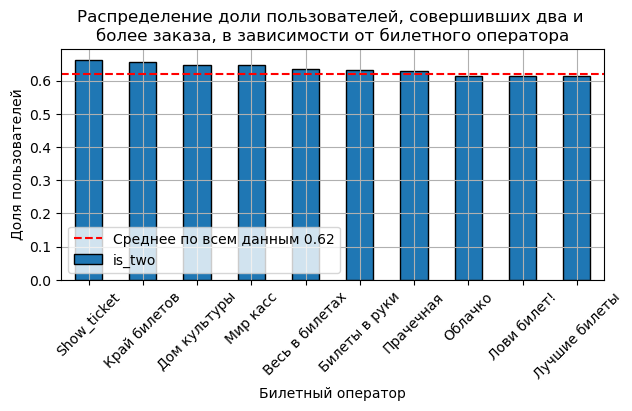

In [76]:
mean_l = profile_service['is_two'].mean().round(2)

grouped.head(10).plot(
    kind='bar',
    figsize=(7, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение доли пользователей, совершивших два и \nболее заказа, в зависимости от билетного оператора',
    xlabel='Билетный оператор',
    ylabel='Доля пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

#### Выводы
- **По типу первого мероприятия**:
  - доли пользователей распределены **равномерно**.
- **По типу устройства**:
    - доли пользователей распределены **равномерно**.
- **По региону**:
    - доли пользователей распределены **равномерно**.
- **По билетному оператору**:
    - доли пользователей распределены **равномерно**.
**Признаки первого заказа не влияют на совершение повторого заказа пользователями.**

---
### Задача 4.1.3. Проверка продуктовых гипотез
- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

In [77]:
grouped = profile[profile['event_type_main'] \
    .isin(['спорт', 'концерты'])] \
    .groupby('event_type_main')['is_two'] \
    .mean()
grouped

event_type_main
концерты   0.62
спорт      0.56
Name: is_two, dtype: float64

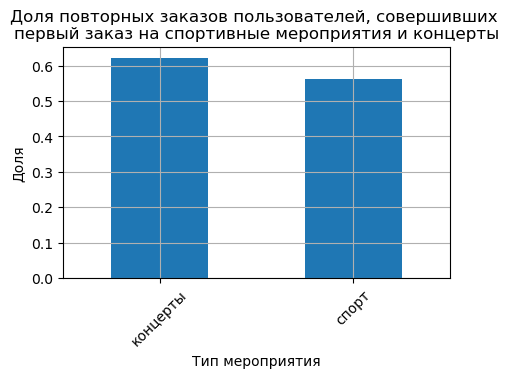

In [78]:
grouped.plot(
        kind='bar',
        figsize=(5, 3),
        grid=True,
        rot=45
    )

plt.title('Доля повторных заказов пользователей, совершивших \nпервый заказ на спортивные мероприятия и концерты')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля')

plt.show()

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [79]:
grouped = profile.groupby('region_name').agg({
    'user_id': lambda x: len(x) / len(profile),
    'is_two': 'mean'
}).sort_values(by='user_id', ascending=False) \
    .head(10)
grouped

,user_id,is_two
region_name,,
Каменевский регион,0.33,0.63
Североярская область,0.17,0.64
Широковская область,0.06,0.65
Озернинский край,0.03,0.55
Малиновоярский округ,0.02,0.56
Шанырский регион,0.02,0.68
Травяная область,0.02,0.62
Светополянский округ,0.02,0.66
Речиновская область,0.02,0.64


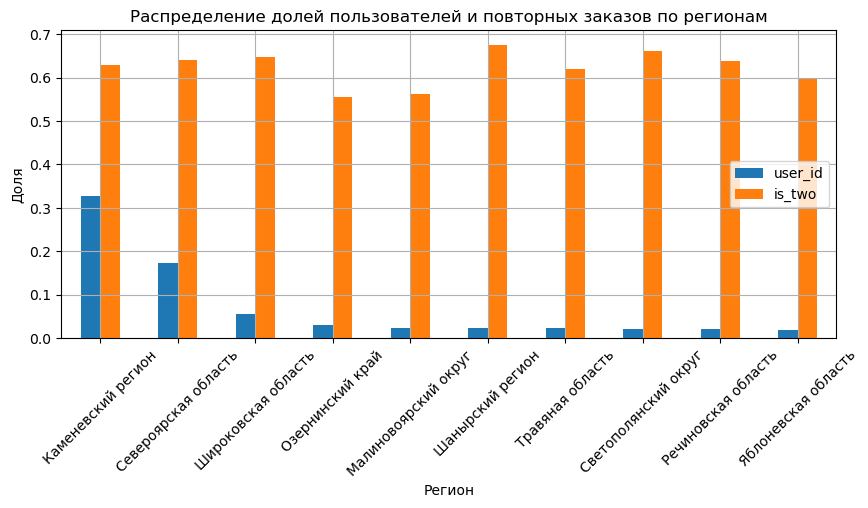

In [80]:
grouped.plot(
        kind='bar',
        figsize=(10, 4),
        grid=True,
        rot=45
    )

plt.title('Распределение долей пользователей и повторных заказов по регионам')
plt.xlabel('Регион')
plt.ylabel('Доля')
plt.legend(loc='center right')

plt.show()

#### Выводы
- **Гипотеза 1.** Пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
    - **Гипотеза 1 не подтверждена**.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.
  - **Гипотеза 2 не подтверждена**.

---
## 4.2. Исследование поведения пользователей через показатели выручки и состава заказа
### Задача 4.2.1. Cвязь между средней выручкой сервиса с заказа и повторными заказами
- Построить сравнительные гистограммы распределения средней выручки с билета ( `avg_revenue_rub` ):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
- Есть ли различия между группами?

- Оценим сиатистические показатели распределений средней выручки.

In [81]:
print('Вернувшиеся пользователи:')
profile.loc[profile['is_two'] == 1, 'avg_revenue_rub'].describe()

Вернувшиеся пользователи:


count   13475.00
mean      544.56
std       366.53
min         0.00
25%       274.98
50%       498.08
75%       739.81
max      2628.42
Name: avg_revenue_rub, dtype: float64

In [82]:
print('Пользователи, совершившие один заказ:')
profile.loc[profile['is_two'] == 0, 'avg_revenue_rub'].describe()

Пользователи, совершившие один заказ:


count   8363.00
mean     545.77
std      519.40
min        0.00
25%      133.06
50%      378.87
75%      830.98
max     2628.42
Name: avg_revenue_rub, dtype: float64

- Построим сравнительные гистограммы распределения средней выручки с билета. 

In [83]:
# Функция для отрисовки гистограммы
def plot_hist(df, groupby, col):
    
    min_avg = int(df[col].min())
    max_avg = round(df[col].max())

    plt.figure(figsize=(10, 5))

    for i in df[groupby].unique():
        df.loc[df[groupby] == i, col].plot(
            kind='hist',
            legend=True,
            label=f'{i}',
            grid=True,
            alpha=0.6,
            bins=range(min_avg, max_avg+1, 50),
            edgecolor='white',
            density=True   
    )

    plt.title(f'Cравнение распределений средней выручки с билета в зависимости от {groupby}')
    plt.xlabel('Средняя выручка с билета')
    plt.ylabel('Плотность вероятности')
    plt.legend(title=f'Значение {groupby}')
    plt.xlim(min_avg, max_avg)

    plt.show()

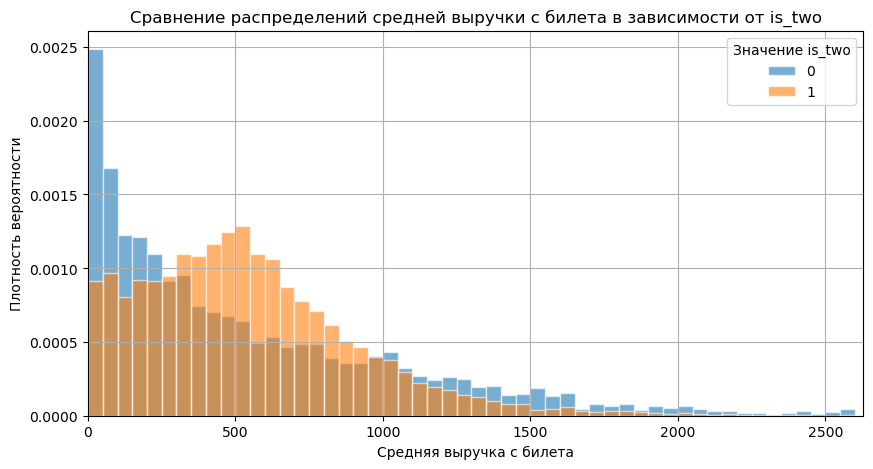

In [84]:
plot_hist(profile, 'is_two', 'avg_revenue_rub')

#### Выводы
- Вернувшиеся пользователи:
    - сконцентрированы в **диапазоне** средней выручки: **300 - 700** руб.
- Пользователи, совершившие один заказ:
    - сконцентрированы в **диапазоне** средней выручки: **0 - 350** руб.
- Распределение средней выручки для вернувшихся пользователей сдвинуто в область более высоких значений.
- **Средняя выручка вернувшихся пользователей в среднем выше по выборке**, чем выручка пользователей, совершивших один заказ.

### Задача 4.2.2. Cвязь между средней выручкой сервиса с заказа и количеством повторных заказов
- Сравните распределение по средней выручке с заказа в двух группах пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

- Оценим статистические показатели по столбцу `total_orders`:

In [85]:
profile['total_orders'].describe().round().astype(int)

count    21838
mean        13
std        122
min          1
25%          1
50%          2
75%          5
max      10167
Name: total_orders, dtype: int64

- Сегментируем пользователей по количеству совершенных заказов:
    - `1 заказ`;
    - `2-4 заказа`;
    - `5 и более заказов`.

In [86]:
profile['orders_seg'] = pd.cut(
    profile['total_orders'],
    bins=[1, 2, 5, 10168],
    labels=['1 заказ', '2-4 заказа', '5 и более заказов'],
    right=False
)

In [87]:
profile['orders_seg'].value_counts(dropna=False)

orders_seg
1 заказ              8363
2-4 заказа           7145
5 и более заказов    6330
Name: count, dtype: int64

- Выводим статистические показатели по средней выручке с заказа в двух группах пользователей.

In [88]:
print('Cовершившие 2–4 заказа:')
profile.loc[profile['orders_seg'] == '2-4 заказа', 'avg_revenue_rub'].describe()

Cовершившие 2–4 заказа:


count   7145.00
mean     552.26
std      420.13
min        0.00
25%      219.50
50%      472.47
75%      798.83
max     2628.42
Name: avg_revenue_rub, dtype: float64

In [89]:
print('Совершившие 5 и более заказов:')
profile.loc[profile['orders_seg'] == '5 и более заказов', 'avg_revenue_rub'].describe()

Совершившие 5 и более заказов:


count   6330.00
mean     535.87
std      294.32
min        0.00
25%      338.36
50%      513.96
75%      690.45
max     2299.87
Name: avg_revenue_rub, dtype: float64

In [90]:
grouped = profile[profile['orders_seg'] != '1 заказ']

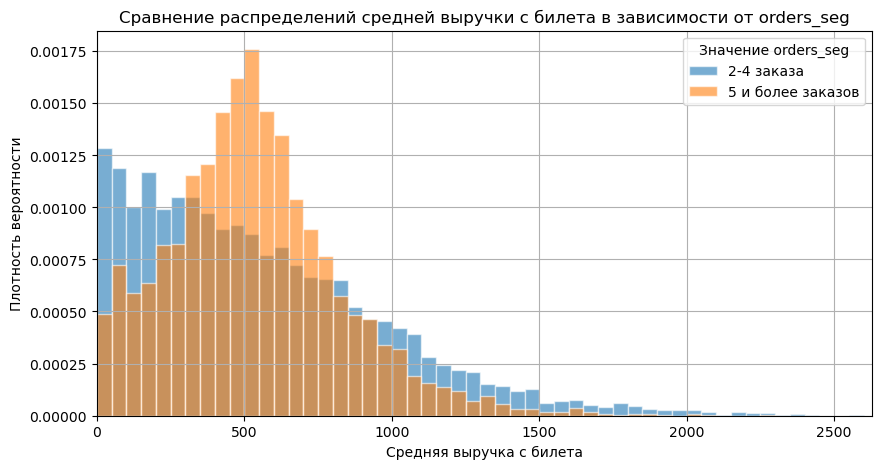

In [91]:
plot_hist(grouped, 'orders_seg', 'avg_revenue_rub')

#### Выводы
- Пользователи, совершившие `2–4 заказа`:
    - сконцентрированы в **диапазоне** средней выручки: **0 - 550** руб.
- Пользователи, совершившие `5 и более заказов`:
    - сконцентрированы в **диапазоне** средней выручки: **350 - 650** руб.
- Распределение средней выручки для пользователей, совершивших 5 и более заказов, сдвинуто в область более высоких значений.
- **Средняя выручка пользователей, совершивших 5 и более заказов, в среднем выше по выборке**, чем выручка пользователей, совершивших 2-4 заказа.

---
### Задача 4.2.3. Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки
- Изучите распределение пользователей по среднему количеству билетов в заказе ( avg_tickets_count ) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Как распределены пользователи по сегментам — равномерно или сконцентрировано?
- Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

- Изучим распределение пользователей по столбцу `avg_tickets_count`

In [92]:
profile['avg_tickets_count'].value_counts() \
    .to_frame(name='Кол-во') \
    .assign(Процент=lambda x: x['Кол-во'] / len(profile) * 100) \
    .style.format({'Процент': '{:.2f}%'})

,Кол-во,Процент
avg_tickets_count,,
3,8479,38.83%
2,7715,35.33%
4,3463,15.86%
1,1461,6.69%
5,547,2.50%
6,162,0.74%
7,5,0.02%
9,2,0.01%
10,2,0.01%


- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе

In [93]:
profile['avg_tickets_seg'] = pd.cut(
    profile['avg_tickets_count'], 
    bins=[1, 2, 3, 5, 12], 
    labels=['1 билет', '2 билета', '3-4 билета', '5-11 билетов'], 
    right=False
)

In [94]:
profile['avg_tickets_seg'].value_counts(dropna=False)

avg_tickets_seg
3-4 билета      11942
2 билета         7715
1 билет          1461
5-11 билетов      720
Name: count, dtype: int64

- Для каждого сегмента подсчитайем общее число пользователей, их долю от общего количества и долю пользователей, совершивших повторные заказы

In [95]:
profile.groupby('avg_tickets_seg', observed=True) \
    .agg(
        total_users=('user_id', 'count'),
        share_total_users=('user_id', lambda x: x.count() / len(profile)),
        share_is_two=('is_two', 'mean')
    ).sort_values(by='total_users', ascending=False)

,total_users,share_total_users,share_is_two
avg_tickets_seg,,,
3-4 билета,11942,0.55,0.65
2 билета,7715,0.35,0.67
1 билет,1461,0.07,0.20
5-11 билетов,720,0.03,0.25


#### Выводы
- Пользователи распределены **по среднему количеству билетов** в заказе **неравномерно**:
    - **3** билета в заказе - **39%** пользователей;
    - **2** билета в заказе - **35%** пользователей.
- Пользователи сконцентрированы в **2-х сегментах**:
    - **3-4 билета** - **55%**;
    - **2 билета** - **35%**;
- **Самая высокая** доля повторных покупок в сегменте **2 билета** - **67%**.
- **Самая низкая** доля повторных покупок в сегменте **1 билет** - **20%**.

---
## 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки
### Задача 4.3.1. Анализ влияния дня недели, в который была совершена первая покупка, на поведение пользователей
- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

- Выделяем день недели

In [96]:
profile['day_of_week'] = profile['first_order_dt'].dt.dayofweek + 1
profile['day_name'] = profile['first_order_dt'].dt.day_name()

- Для каждого дня недели считаем общее число пользователей и долю пользователей, совершивших повторные заказы

In [97]:
grouped = profile.groupby(['day_of_week', 'day_name']).agg(
    total_users=('user_id', 'count'),
    share_users=('user_id', lambda x: round(len(x) / len(profile), 2)),
    share_is_two=('is_two', lambda x: round(x.mean(), 2))
).reset_index().set_index('day_name')
grouped

,day_of_week,total_users,share_users,share_is_two
day_name,,,,
Monday,1,2931,0.13,0.63
Tuesday,2,3188,0.15,0.62
Wednesday,3,3076,0.14,0.62
Thursday,4,3119,0.14,0.60
Friday,5,3258,0.15,0.60
Saturday,6,3456,0.16,0.64
Sunday,7,2810,0.13,0.61


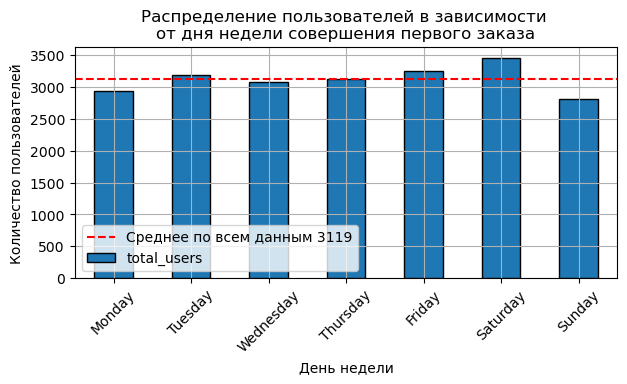

In [98]:
mean_l = grouped['total_users'].mean().round(2).astype(int)

grouped['total_users'].plot(
    kind='bar',
    figsize=(7, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение пользователей в зависимости \nот дня недели совершения первого заказа',
    xlabel='День недели',
    ylabel='Количество пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

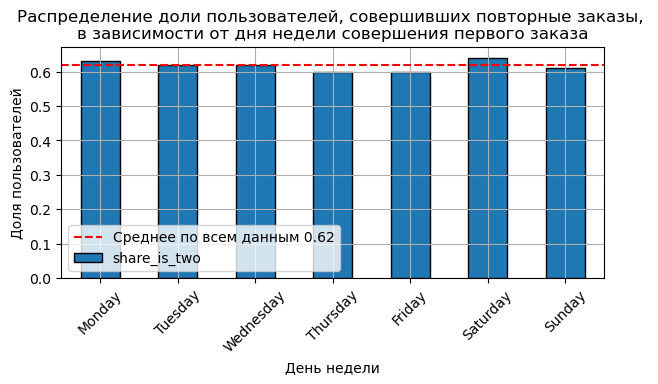

In [99]:
mean_l = grouped['share_is_two'].mean().round(2)

grouped['share_is_two'].plot(
    kind='bar',
    figsize=(7, 3),
    edgecolor='black',
    grid=True,
    rot=45,
    title='Распределение доли пользователей, совершивших повторные заказы, \nв зависимости от дня недели совершения первого заказа',
    xlabel='День недели',
    ylabel='Доля пользователей'
)

plot_axhline(mean_l, 'Среднее по всем данным ')

plt.legend()
plt.show()

#### Выводы
- Пользователи распределены **равномерно** по дням недели совершения первой покупки.
- Вероятность повторных заказов **примерно одинакова**.
- Однако, стоит отметить, что **в субботу**:
    - **наибольшее** число пользователей - **16%** совершили свою первую покупку;
    - **наибольшая** вероятность возврата клиента - **64%**.

---
### Задача 4.3.2. Влияние среднего интервала между заказами на удержание клиентов
- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

In [100]:
profile[profile['orders_seg'] != '1 заказ'] \
    .groupby('orders_seg', observed=True) \
    .agg(
        avg_days=('avg_days', lambda x: round(x.mean()))
    ).sort_values(by='avg_days', ascending=False)

,avg_days
orders_seg,
2-4 заказа,21
5 и более заказов,10


- Считаем вероятность повторного заказа в зависимости от среднего интервала между заказами

In [101]:
grouped = profile[profile['avg_days'] != -1].groupby('avg_days') \
    .agg(
        retention=('user_id', lambda x: x.count() / len(profile))
)
grouped

,retention
avg_days,
0,0.14
1,0.03
2,0.02
3,0.02
4,0.02
...,...
144,0.00
145,0.00
146,0.00


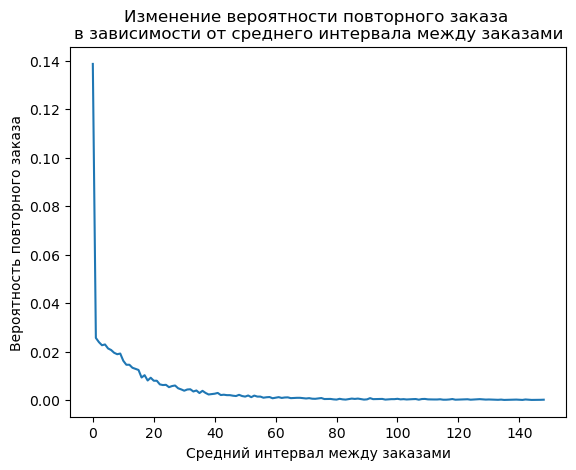

In [102]:
grouped.plot(
    kind='line',
    title='Изменение вероятности повторного заказа \nв зависимости от среднего интервала между заказами',
    legend=False
)

plt.xlabel('Средний интервал между заказами')
plt.ylabel('Вероятность повторного заказа')


plt.show()

#### Выводы
- **Cреднее время между заказами** для пользователей:
    - совершивших **2–4 заказа** - **21 день**;
    - совершившие **5 и более заказов** - **10 дней**.
- Чем **меньше средний интервал** между заказами, тем **выше вероятность** повторного заказа.

## 4.4. Корреляционный анализ количества покупок и признаков пользователя
### Задача 4.4.1. Проведение корреляционного анализа
- Рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов ( total_orders ). При необходимости используйте параметр interval_cols для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в total_orders. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю total_orders, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Какие признаки наиболее связаны с количеством заказов?

- Рассчитаем коэффициент корреляции **phi_k** между признаками профиля пользователя и числом заказов `total_orders`

In [103]:
col_list = profile.columns.difference(['user_id']).to_list() 

In [104]:
corr_matrix = profile[col_list].phik_matrix(interval_cols=['avg_days', 'avg_revenue_rub', 'avg_tickets_count', 'total_orders'])
heat_map = corr_matrix.loc[corr_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
heat_map

,total_orders
first_order_dt,0.16
region_name,0.13
service_name,0.10
orders_seg,0.09
is_five,0.08
day_of_week,0.06
day_name,0.06
is_two,0.03
avg_tickets_seg,0.02
avg_days,0.00


- Проверим разброс данных в `total_orders`

In [105]:
profile['total_orders'].value_counts() / len(profile)

total_orders
1     0.38
2     0.16
3     0.10
4     0.06
5     0.04
      ... 
667   0.00
653   0.00
357   0.00
392   0.00
130   0.00
Name: count, Length: 326, dtype: float64

В данных преобладает значение **1**. В таком случае корреляционный анализ может показать отсутствие связей. 

- Рассчитаем коэффициент корреляции **phi_k** между признаками профиля пользователя и сегментом по количеству заказов `orders_seg`:

In [106]:
heat_map = corr_matrix.loc[corr_matrix.index != 'orders_seg'][['orders_seg']].sort_values(by='orders_seg', ascending=False)
heat_map

,orders_seg
is_five,1.00
is_two,1.00
last_order_dt,0.62
first_order_dt,0.59
avg_days,0.55
avg_tickets_count,0.41
avg_revenue_rub,0.33
avg_tickets_seg,0.22
region_name,0.13
total_orders,0.09


- Визуализируем результат корреляции с помощью тепловой карты 

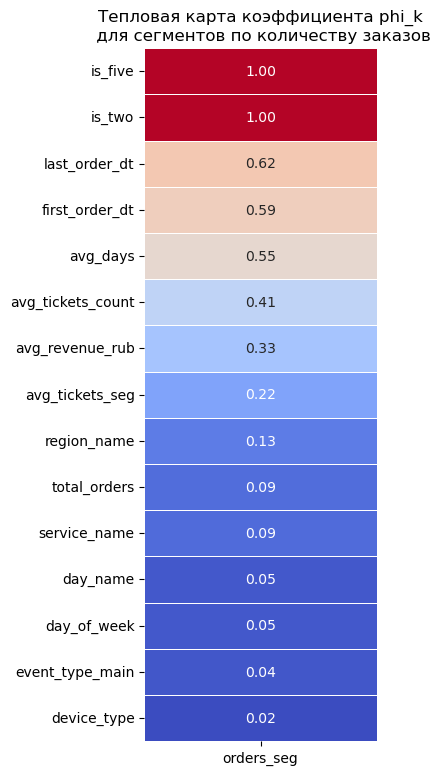

In [107]:
plt.figure(figsize=(3, 9))

sns.heatmap(
    heat_map,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=False
)

plt.title('Тепловая карта коэффициента phi_k\n для сегментов по количеству заказов')

plt.show()

#### Выводы
- **Макимальная корреляция**:
    - is_five - **1**;
    - is_two - **1**.
- **Сильная корреляция**:
    - last_order_dt - **0.62**;
    - first_order_dt - **0.59**;
    - avg_days - **0.55**.

# 5. Итоговый вывод и рекомендации
## 5.1. Загрузка данных и предобработка 
- Выгрузили данные из базы данных PostgreSQL `data-analyst-afisha`: **15 столбцов и 290611 строк**.
- Загрузили данные датасета `final_tickets_tenge_df.csv` для перевода тенге в рубли: **4 столбца и 357 строк**.
- Преобразовали числовые типы данных с понижением размерности.
- Создали дополнительный столбец `revenue_rub` с выручкой в российских рублях.
- Изучили пропуски в данных. Пропуски обнаружены в столбце `days_since_prev`. **Все пропуски оставили как есть**.
- **120 дубликатов удалено**.
- **3203 строки отфильтровано**.
- Для дальнейшего анализа подготовлен датафрейм `df`, содержащий **287288 строк и 16 столбцов**.
- **Всего удалено 3323 строки - 1.14% данных**.



## 5.2. Основные результаты анализа
- **Характеристики выборки**:
    - общее число пользователей - **21838**;
    - средняя выручка с одного заказа - **545 руб**;
    - доля пользователей, совершивших 2 и более заказа - **62%**;
    - доля пользователей, совершивших 5 и более заказов - **29%**.
- **Статистические показатели**:
    - по общему числу заказов:
        - среднее значение - **13**, медиана - **2**;
        - минимальное значение - **1**, максимальное - **10167**;
    - по среднему числу билетов в заказе:
        - среднее значение - **3**, медиана - **3**;
        - минимальное значение - **1**, максимальное - **11**;
    - по среднему количеству дней между покупками:
        - среднее значение - **9**, медиана - **0**;
        - минимальное значение - **-1** (у пользователя был только один заказ), максимальное - **148**.
- **Признаки первого заказа**:
    - тип первого мероприятия:
        - сегмент с наибольшим числом пользователей: **концерты - 44,2%**;
    - тип устройства:
        - **mobile - 82,8%**;
        - **desktop - 17,2%**;
    - регион:         
        - **Каменевский регион - 32,8%**;
        - **Североярская область - 17,4%**;
    - билетный оператор:
        - **Билеты без проблем - 23.8%**.
- **Признаки первого заказа не влияют на совершение повторого заказа пользователями.**
- **Средняя выручка вернувшихся пользователей в среднем выше по выборке**, чем выручка пользователей, совершивших один заказ.
- **Средняя выручка пользователей, совершивших 5 и более заказов, в среднем выше по выборке**, чем выручка пользователей, совершивших 2-4 заказа.
- **Вероятность повторных покупок**:
    - **67%** - в сегменте 2 билета, **35% пользователей**;
    - **65%** - в сегменте 3-4 билета, **55% пользователей**.
- Влияние **временных характеристик** на удержание:
    - **в субботу**:
        - наибольшее число пользователей - **16%** совершили свою первую покупку;
        - наибольшая вероятность возврата клиента - **64%**;
     - чем **меньше средний интервал** между заказами, тем **выше вероятность** повторного заказа.
- Согласно результатам корреляционного анализа **сильная корреляция** наблюдается **между числом покупок** и следующими характеристиками профиля пользователя:
    - **дата последнего заказа** - **0.62**;
    - **дата первого заказа** - **0.59**;
    - **средний интервал между заказами** - **0.55**.

## 5.3. Рекомендации
1. **Приоритетные сегменты**
- Основной фокус:
    - сегмент пользователей с **3–4 билетами в заказе**;
    - самый перспективный сегмент: **55%** от всех пользователей, вероятность возврата - **65%**.
- Второе направление:
    - сегмент пользователей с **2 билетами в заказе**;
    - **35%** пользователей, вероятность возврата - **67%**;
    - **конверсия** в повторную покупку **выше**, но объём сегмента меньше.
2. **Стратегии для увеличения повторных покупок**
- Стимулирование объёма первого заказа:
    - **акции** или **скидки** на билеты в корзине;
    - **специальные тарифы** для компаний и семей;
    - подборки мероприятий.
- **Персонализация** для пользователей с 3–4 билетами в заказе:
    - подборки похожих мероприятий;
    - предложения с групповыми скидками на будущие события.
3. **Удержание и повышение частоты покупок**
- Работа с временными интервалами между покупками:
    - **для активных** пользователей — регулярные персональные рассылки с анонсами;
    - для тех, кто **давно не покупал** — триггерные кампании по возврату с персональными предложениями, основанными на их предыдущих покупках.
- Акцент на **мобильных** пользователях:
    - все механики по стимуляции объёма и удержанию должны быть в первую очередь реализованы в мобильном приложении.
4. **География и ассортимент**
- Региональная специфика:
    - **Каменевский регион и Североярская область** - **50.2%** пользователей;
    - Для них стоит делать **локальные подборки и акции**.
- Фокус на концертах:
    - **концерты** — самый популярный тип первого мероприятия: **44,2%**;
    - в этом сегменте нужно активнее всего стимулировать покупку нескольких билетов и предлагать повторные покупки.
### Вывод
- **Основная точка роста** — увеличение объёма первого заказа, особенно стимулирование покупки 3–4 билетов.
- **Сегмент пользователей с 3–4 билетами в заказе** - самый массовый и перспективный сегмент для формирования лояльности.
- Все маркетинговые усилия должны быть направлены на то, чтобы **пользователь с первого раза вовлёкся в экосистему сервиса через коллективное посещение мероприятий**.
